In [1]:
# STEP 0 — 라이브러리 임포트 & 카메라 파라미터
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import Optional, Tuple, List

def get_kitti_camera_params() -> dict:
    P = np.array([
        [707.0912,   0.0,      601.8873, 0.0],
        [  0.0,    707.0912,  183.1104, 0.0],
        [  0.0,      0.0,      1.0,     0.0]
    ], dtype=np.float64)
    K = P[:3, :3].copy()
    R = np.eye(3, dtype=np.float64)
    t = np.zeros((3, 1), dtype=np.float64)
    h = 1.65
    return {"K": K, "P": P, "R": R, "t": t, "h": h}

params = get_kitti_camera_params()
K, R, h = params["K"], params["R"], params["h"]
print("✅ STEP 0 완료 — 카메라 파라미터 로드")
print(f"   K =\n{K}")

✅ STEP 0 완료 — 카메라 파라미터 로드
   K =
[[707.0912   0.     601.8873]
 [  0.     707.0912 183.1104]
 [  0.       0.       1.    ]]


✅ STEP 1 완료 — 소실점 & ROI 생성
   이미지 크기 : 1226 × 370
   소실점 좌표 : (601, 183)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3516874412.py:57: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3516874412.py:57: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3516874412.py:57: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3516874412.py:57: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3516874412.py:57: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
c:\Users\u

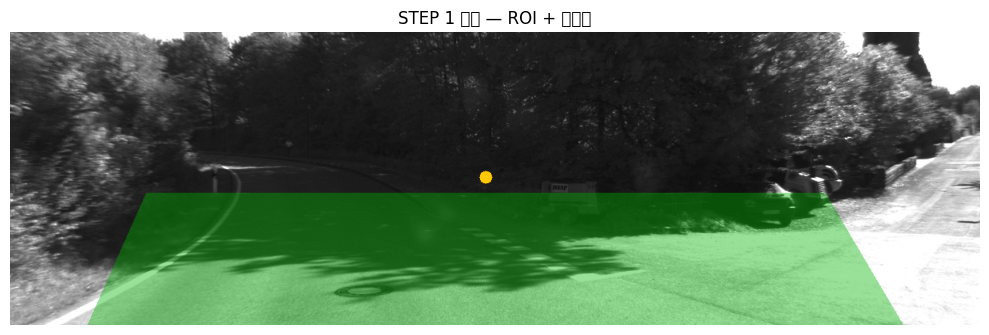

In [2]:
# STEP 1 — 소실점 추정 & 사다리꼴 ROI 생성

def estimate_vanishing_point(img_h: int, img_w: int,
                              K: np.ndarray, R: np.ndarray) -> Tuple[int, int]:
    """
    소실점 = K · R · d_forward  (d_forward = [0,0,1])
    t 항은 무한대 점 투영 시 소거되므로 포함하지 않음.
    """
    d = np.array([0.0, 0.0, 1.0])
    vp = K @ R @ d
    vp_x = int(np.clip(vp[0] / vp[2], 0, img_w - 1))
    vp_y = int(np.clip(vp[1] / vp[2], 0, img_h - 1))
    return vp_x, vp_y


def create_trapezoid_roi(img_h: int, img_w: int,
                          vp_x: int, vp_y: int) -> np.ndarray:
    """
    소실점을 상단 꼭짓점 기준으로 도로 영역 사다리꼴 마스크 생성.
    3D 평행 차선이 2D 이미지에서 소실점으로 수렴하는 성질 이용.
    """
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    y_top = int(img_h * 0.55)
    y_bot = img_h - 1
    half_w_top = int(img_w * 0.35)
    pts = np.array([
        [vp_x - half_w_top, y_top],
        [vp_x + half_w_top, y_top],
        [img_w - int(img_w * 0.08), y_bot],
        [int(img_w * 0.08),          y_bot],
    ], dtype=np.int32)
    cv2.fillPoly(mask, [pts], 255)
    return mask


# 동작 확인 (첫 번째 이미지 기준)
KITTI_DIR  = r"D:\user\Downloads\data_odometry_gray\dataset\sequences\09\image_0"
OUTPUT_DIR = r"D:\user\Downloads\kitti_results"

sample_path = sorted(glob.glob(os.path.join(KITTI_DIR, "*.png")))[0]
sample_gray = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
img_h, img_w = sample_gray.shape

vp_x, vp_y = estimate_vanishing_point(img_h, img_w, K, R)
roi_mask    = create_trapezoid_roi(img_h, img_w, vp_x, vp_y)

print("✅ STEP 1 완료 — 소실점 & ROI 생성")
print(f"   이미지 크기 : {img_w} × {img_h}")
print(f"   소실점 좌표 : ({vp_x}, {vp_y})")

# 확인용 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
vis = cv2.cvtColor(sample_gray, cv2.COLOR_GRAY2RGB)
vis[roi_mask > 0] = (vis[roi_mask > 0] * 0.6 + np.array([0, 180, 0]) * 0.4).astype(np.uint8)
cv2.circle(vis, (vp_x, vp_y), 8, (255, 200, 0), -1)
ax.imshow(vis); ax.set_title("STEP 1 확인 — ROI + 소실점"); ax.axis('off')
plt.tight_layout(); plt.show()

In [3]:
# STEP 2 — Bayesian 도로 검출기 클래스 정의

class BayesianRoadDetector:
    """
    MAP(Maximum A Posteriori) 기반 도로/배경 이진 분류기.

    수식 요약:
      Likelihood  : P(I=i | class) = (count[i] + ε) / (N + ε·256)  ← Laplace smoothing
      Temporal    : hist_t = α·hist_{t-1} + (1-α)·hist_t            ← 시계열 일관성
      Prior       : P(road) = ROI픽셀수 / 전체픽셀수
      MAP 결정    : class* = argmax_c [ log P(I|c) + log P(c) ]
    """

    def __init__(self, n_bins: int = 256, alpha: float = 0.8,
                 laplace_eps: float = 1.0):
        self.n_bins = n_bins
        self.alpha  = alpha
        self.eps    = laplace_eps
        self._prev_road: Optional[np.ndarray] = None
        self._prev_bg:   Optional[np.ndarray] = None

    def _histogram(self, gray: np.ndarray, mask: np.ndarray) -> np.ndarray:
        pixels = gray[mask > 0].flatten()
        if len(pixels) == 0:
            return np.ones(self.n_bins, dtype=np.float64) / self.n_bins
        counts, _ = np.histogram(pixels, bins=self.n_bins, range=(0, 256))
        counts     = counts.astype(np.float64) + self.eps   # Laplace smoothing
        return counts / counts.sum()

    def _temporal(self, hr: np.ndarray, hb: np.ndarray):
        if self._prev_road is None:
            self._prev_road = hr.copy()
            self._prev_bg   = hb.copy()
            return hr, hb
        sr = self.alpha * self._prev_road + (1 - self.alpha) * hr
        sb = self.alpha * self._prev_bg   + (1 - self.alpha) * hb
        sr /= sr.sum(); sb /= sb.sum()
        self._prev_road = sr.copy()
        self._prev_bg   = sb.copy()
        return sr, sb

    def detect(self, gray: np.ndarray,
               roi_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        img_h, img_w = gray.shape
        bg_mask = ((~roi_mask.astype(bool)) * 255).astype(np.uint8)

        hr, hb   = self._histogram(gray, roi_mask), self._histogram(gray, bg_mask)
        hr, hb   = self._temporal(hr, hb)

        n_road   = float(np.count_nonzero(roi_mask))
        prior_r  = n_road / (img_h * img_w)
        prior_b  = 1.0 - prior_r

        flat     = gray.flatten().astype(np.int32)
        log_r    = np.log(hr[flat] + 1e-12) + np.log(prior_r + 1e-12)
        log_b    = np.log(hb[flat] + 1e-12) + np.log(prior_b + 1e-12)

        # 확률 맵 (sigmoid of log-odds)
        prob_map = (1.0 / (1.0 + np.exp(-(log_r - log_b).clip(-50, 50)))
                    ).reshape(img_h, img_w).astype(np.float32)

        # MAP 이진 마스크 + 모폴로지 후처리
        binary   = (log_r > log_b).reshape(img_h, img_w) & roi_mask.astype(bool)
        mask_out = (binary * 255).astype(np.uint8)
        k        = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_CLOSE, k)
        mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_OPEN,  k)
        return mask_out, prob_map


print("✅ STEP 2 완료 — BayesianRoadDetector 클래스 정의")

✅ STEP 2 완료 — BayesianRoadDetector 클래스 정의


In [4]:
# STEP 3 — 차선 후보 추출 함수 정의

def extract_lanes(prob_map: np.ndarray,
                  road_mask: np.ndarray,
                  vp_y: int, vp_x: int
                  ) -> Tuple[List, List]:
    """
    Bayesian 도로 확률 맵 + 이진 마스크를 결합하여 차선 후보 추출.

    파이프라인:
      1. prob_map을 uint8로 변환 후 road_mask로 마스킹
      2. GaussianBlur → Canny 엣지
      3. Sobel 크기 → 이진화 엣지
      4. Canny | Sobel 합산
      5. Probabilistic Hough Transform → 선분 목록
      6. 필터링: 소실점 위 선분 제거, 수평선 제거
      7. 소실점 기준 좌(음의 기울기) / 우(양의 기울기) 분류
    """
    prob_u8 = (prob_map * 255).astype(np.uint8)
    masked  = cv2.bitwise_and(prob_u8, prob_u8, mask=road_mask)
    blurred = cv2.GaussianBlur(masked, (5, 5), 0)

    # Canny
    edges_c = cv2.Canny(blurred, 30, 80)

    # Sobel
    sx  = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    edges_s = cv2.threshold(mag, 50, 255, cv2.THRESH_BINARY)[1]

    edges = cv2.bitwise_or(edges_c, edges_s)

    raw = cv2.HoughLinesP(edges, 1, np.pi / 180,
                          threshold=50, minLineLength=40, maxLineGap=20)
    if raw is None:
        return [], []

    left, right = [], []
    for line in raw:
        x1, y1, x2, y2 = line[0]
        if y1 < vp_y and y2 < vp_y:   # 소실점 위 제거
            continue
        dx = x2 - x1
        if abs(dx) < 1e-6:
            continue
        slope = (y2 - y1) / dx
        if abs(slope) < 0.2:           # 수평선 제거
            continue
        cx = (x1 + x2) / 2
        if slope < 0 and cx < vp_x:
            left.append((x1, y1, x2, y2))
        elif slope > 0 and cx > vp_x:
            right.append((x1, y1, x2, y2))

    return left, right


print("✅ STEP 3 완료 — extract_lanes 함수 정의")

✅ STEP 3 완료 — extract_lanes 함수 정의


In [5]:
# STEP 4 — 오버레이 이미지 합성 함수 정의

def make_overlay(gray: np.ndarray,
                 road_mask: np.ndarray,
                 left_lines: List,
                 right_lines: List,
                 vp_x: int, vp_y: int) -> np.ndarray:
    """
    단일 패널 오버레이 합성:
      - 도로 마스크 : 반투명 초록 (alpha=0.35)
      - 왼쪽 차선   : 빨강  (BGR: 80,80,255)
      - 오른쪽 차선 : 파랑  (BGR: 255,80,80)
      - 소실점      : 노랑 원 (BGR: 0,255,255)
    """
    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    green = np.zeros_like(overlay)
    green[road_mask > 0] = [0, 200, 0]
    overlay = cv2.addWeighted(overlay, 1.0, green, 0.35, 0)

    for x1, y1, x2, y2 in left_lines:
        cv2.line(overlay, (x1, y1), (x2, y2), (80, 80, 255), 2)
    for x1, y1, x2, y2 in right_lines:
        cv2.line(overlay, (x1, y1), (x2, y2), (255, 80, 80), 2)

    cv2.circle(overlay, (vp_x, vp_y), 8,  (0, 255, 255), -1)
    cv2.circle(overlay, (vp_x, vp_y), 14, (0, 200, 200),  2)

    return overlay


print("✅ STEP 4 완료 — make_overlay 함수 정의")

✅ STEP 4 완료 — make_overlay 함수 정의


In [7]:
# STEP 5 — 전체 1590장 처리 및 저장

os.makedirs(OUTPUT_DIR, exist_ok=True)

img_paths   = sorted(glob.glob(os.path.join(KITTI_DIR, "*.png")))
total       = len(img_paths)
detector    = BayesianRoadDetector(n_bins=256, alpha=0.8, laplace_eps=1.0)
saved_paths = []

print(f"총 {total}장 처리 시작...\n")

for idx, img_path in enumerate(img_paths):
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        print(f"  [SKIP] {os.path.basename(img_path)}")
        continue

    img_h, img_w = gray.shape

    # Step 1: 소실점 + ROI
    vp_x, vp_y = estimate_vanishing_point(img_h, img_w, K, R)
    roi_mask    = create_trapezoid_roi(img_h, img_w, vp_x, vp_y)

    # Step 2: Bayesian 도로 마스크
    road_mask, prob_map = detector.detect(gray, roi_mask)

    # Step 3: 차선 추출
    left_lines, right_lines = extract_lanes(prob_map, road_mask, vp_y, vp_x)

    # Step 4: 오버레이 합성 & 저장
    overlay   = make_overlay(gray, road_mask, left_lines, right_lines, vp_x, vp_y)
    save_path = os.path.join(OUTPUT_DIR, f"result_{idx:06d}.png")
    cv2.imwrite(save_path, overlay)
    saved_paths.append(save_path)

    # 50장마다 진행 상황 출력
    if (idx + 1) % 50 == 0 or (idx + 1) == total:
        print(f"  [{idx+1:4d}/{total}] ✓ {save_path}")

print(f"\n✅ STEP 5 완료 — {len(saved_paths)}장 저장 → {OUTPUT_DIR}")

총 1591장 처리 시작...

  [  50/1591] ✓ D:\user\Downloads\kitti_results\result_000049.png
  [ 100/1591] ✓ D:\user\Downloads\kitti_results\result_000099.png
  [ 150/1591] ✓ D:\user\Downloads\kitti_results\result_000149.png
  [ 200/1591] ✓ D:\user\Downloads\kitti_results\result_000199.png
  [ 250/1591] ✓ D:\user\Downloads\kitti_results\result_000249.png
  [ 300/1591] ✓ D:\user\Downloads\kitti_results\result_000299.png
  [ 350/1591] ✓ D:\user\Downloads\kitti_results\result_000349.png
  [ 400/1591] ✓ D:\user\Downloads\kitti_results\result_000399.png
  [ 450/1591] ✓ D:\user\Downloads\kitti_results\result_000449.png
  [ 500/1591] ✓ D:\user\Downloads\kitti_results\result_000499.png
  [ 550/1591] ✓ D:\user\Downloads\kitti_results\result_000549.png
  [ 600/1591] ✓ D:\user\Downloads\kitti_results\result_000599.png
  [ 650/1591] ✓ D:\user\Downloads\kitti_results\result_000649.png
  [ 700/1591] ✓ D:\user\Downloads\kitti_results\result_000699.png
  [ 750/1591] ✓ D:\user\Downloads\kitti_results\result_000

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3727218806.py:25: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3727218806.py:25: UserWarning: Glyph 45924 (\N{HANGUL SYLLABLE DEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3727218806.py:25: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3727218806.py:25: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\3727218806.py:25: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_56708\372

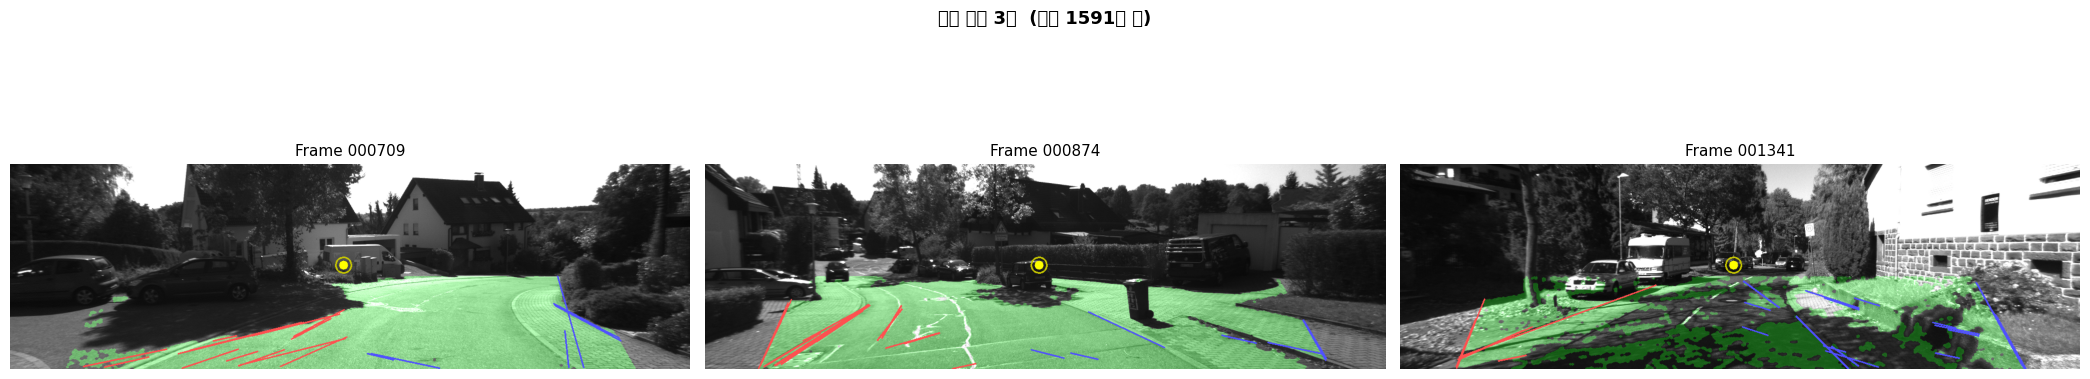

✅ STEP 6 완료 — 랜덤 샘플 출력


In [8]:
# STEP 6 — 랜덤 3장 선택 & 채팅창(matplotlib) 출력

def show_random_samples(saved_paths: List[str], n: int = 3) -> None:
    """
    저장된 결과 중 랜덤 n장을 1행 n열로 출력합니다.
    선택된 프레임 번호를 제목으로 표시합니다.
    """
    samples = random.sample(saved_paths, min(n, len(saved_paths)))
    samples.sort()  # 시간순 정렬

    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    fig.suptitle(
        f"랜덤 샘플 {n}장  (전체 {len(saved_paths)}장 중)",
        fontsize=13, fontweight='bold'
    )

    for ax, path in zip(axes, samples):
        img       = cv2.imread(path)
        img       = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        frame_num = int(os.path.splitext(os.path.basename(path))[0].split("_")[1])
        ax.imshow(img)
        ax.set_title(f"Frame {frame_num:06d}", fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_random_samples(saved_paths, n=3)
print("✅ STEP 6 완료 — 랜덤 샘플 출력")

## 이미지 좌표의 차선

이미지에서 차선은 직선으로 표시됩니다. 직선 위의 픽셀들은 각각 하나씩 광선을 정의하고, 그 광선들은 모두 카메라 원점(O) 을 지납니다. 그러나 이 평면만으로는 차선이 실제로 얼마나 멀리 있는지(λ 값) 를 알 수 없습니다. 깊이(depth) 정보가 없기 때문입니다.


## 도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성

3D의 평행 차선이 2D에서 사다리꼴처럼 보입니다. 거리가 멀어질수록 이미지에서 차선 간격이 좁아지고, 무한히 멀어지면 한 점(소실점)으로 모이이도록 보이기 때문입니다.


## projection matrix와 차선의 기울기, 소실점(vanishing point) 간의 관계

P = K · [R | t]     (3×4 행렬)

K : 3×3 내부 파라미터 (초점거리 fx, fy / 주점 cx, cy)
R : 3×3 회전 행렬    (카메라 자세)
t : 3×1 이동 벡터   (카메라 위치)